## 1. Environment Initialization & Data Ingestion
This pipeline ingests univariate time series data to evaluate structural characteristics and establish predictive baselines. The dataset is formatted to a strict daily frequency, utilizing forward filling to handle missing temporal gaps and ensure uniform intervals for distance based and auto regressive computations.

In [2]:
pip install pmdarima prophet statsmodels scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 5.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# Ingestion
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(URL, parse_dates=['Date'], index_col='Date')
df = df.asfreq('D').ffill()

# Structural Validation
display(df.head())
df.info()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3652 entries, 1981-01-01 to 1990-12-31
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3652 non-null   float64
dtypes: float64(1)
memory usage: 57.1 KB


## 2. Global Variance & Trend Inspection
Visual inspection of the macro level distribution is required to identify explicit non-linear trends, heteroscedasticity, or seasonal periodicity prior to formal statistical testing.

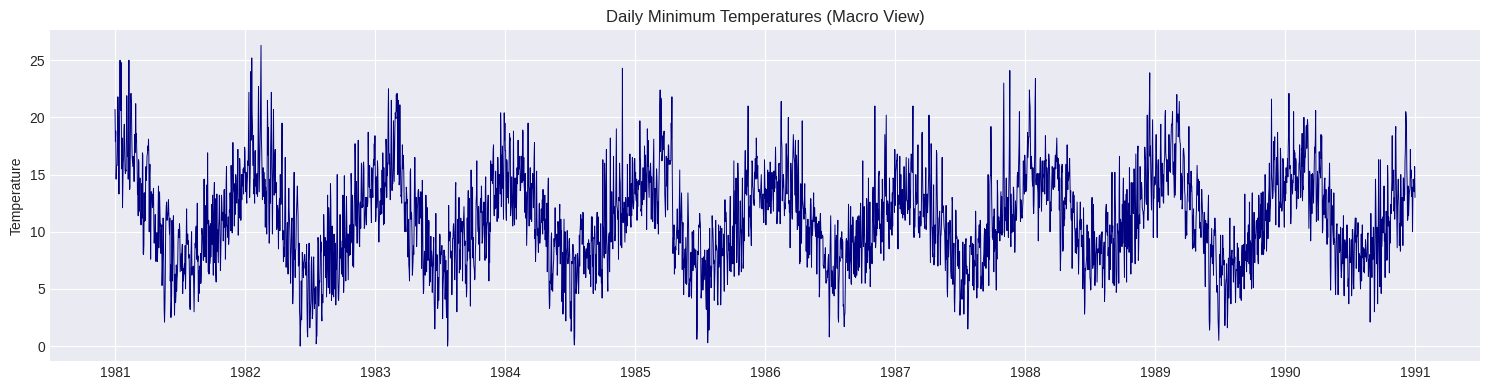

,count,mean,std,min,25%,50%,75%,max
Temp,3652.0,11.179984,4.071925,0.0,8.3,11.0,14.0,26.3


In [4]:
plt.figure(figsize=(15, 4))
plt.plot(df.index, df['Temp'], color='navy', linewidth=0.7)
plt.title('Daily Minimum Temperatures (Macro View)')
plt.ylabel('Temperature')
plt.tight_layout()
plt.show()

display(df.describe().T)

## 3. Mathematical Stationarity Validation (ADF Test)
ARIMA architectures assume the underlying time series is stationary. We apply the Augmented Dickey Fuller (ADF) test, which assesses the presence of a unit root in the autoregressive model. The hypothesis test is defined as:
*   $H_0$ (Null): The time series possesses a unit root (is non-stationary).
*   $H_1$ (Alternate): The time series is strictly stationary.

If the $p$-value $< 0.05$, we reject $H_0$ and conclude that differencing ($d=0$) is sufficient.

In [5]:
adf_result = adfuller(df['Temp'].dropna())

print("--- Augmented Dickey-Fuller Test Results ---")
print(f"Test Statistic: {adf_result[0]:.4f}")
print(f"P-Value: {adf_result[1]:.4e}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nStatistical Conclusion: Reject H0. The series is stationary.")
else:
    print("\nStatistical Conclusion: Fail to reject H0. The series is non-stationary. Differencing required.")

--- Augmented Dickey-Fuller Test Results ---
Test Statistic: -4.4409
P-Value: 2.5105e-04
Critical Values:
   1%: -3.4322
   5%: -2.8623
   10%: -2.5672

Statistical Conclusion: Reject H0. The series is stationary.


## 4. Autocorrelation (ACF) & Partial Autocorrelation (PACF)
The ACF measures the linear dependence between the time series and lagged versions of itself, while the PACF isolates the direct correlation by removing the influence of intermediate lags. These plots provide empirical bounds for the Moving Average ($q$) and Auto-Regressive ($p$) parameters respectively.

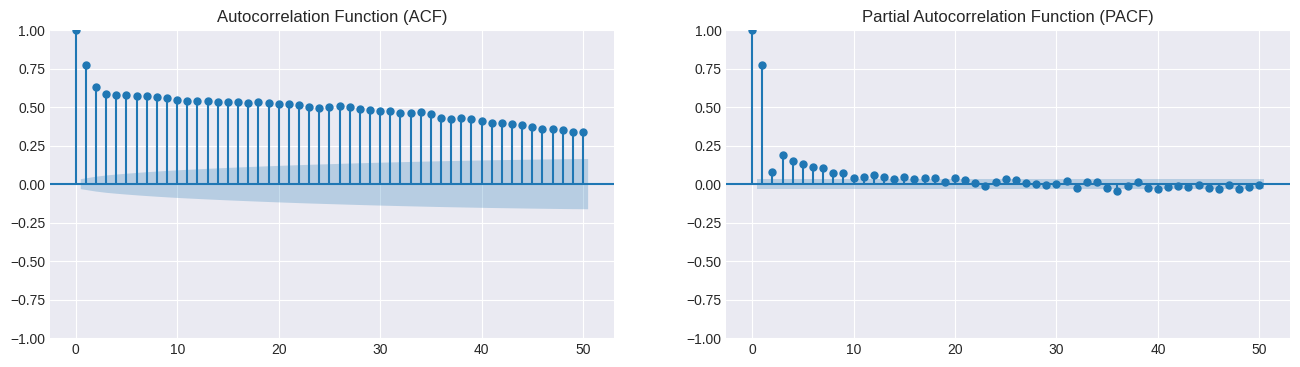

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['Temp'].dropna(), ax=axes[0], lags=50, alpha=0.05)
plot_pacf(df['Temp'].dropna(), ax=axes[1], lags=50, alpha=0.05)
axes[0].set_title('Autocorrelation Function (ACF)')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.show()

## 5. Data Partitioning
A chronological split (80% Training, 20% Testing) is enforced to prevent data leakage and evaluate the models on unseen future variances.

In [7]:
split_idx = int(len(df) * 0.8)
train, test = df.iloc[:split_idx], df.iloc[split_idx:]

print(f"Training Domain: {train.index.min().date()} to {train.index.max().date()} ({len(train)} obs)")
print(f"Testing Domain:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} obs)")

Training Domain: 1981-01-01 to 1988-12-30 (2921 obs)
Testing Domain:  1988-12-31 to 1990-12-31 (731 obs)


## 6. Auto-Regressive Integrated Moving Average (ARIMA)
We utilize a grid-search algorithm to optimize the $ARIMA(p, d, q)$ parameters. The objective function minimizes the Akaike Information Criterion (AIC):
$$AIC = 2k - 2\ln(\hat{L})$$
Where $k$ represents the number of estimated parameters and $\hat{L}$ is the maximum value of the likelihood function.

In [8]:
arima_model = pm.auto_arima(
    train['Temp'],
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    d=None,
    seasonal=False,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(arima_model.summary())

# Generate forecasts and 95% Confidence Intervals
arima_preds, arima_conf_int = arima_model.predict(n_periods=len(test), return_conf_int=True)
arima_preds.index = test.index

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2921
Model:               SARIMAX(3, 0, 1)   Log Likelihood               -6765.432
Date:                Mon, 24 Aug 2026   AIC                          13542.864
Time:                        18:31:48   BIC                          13578.742
Sample:                    01-01-1981   HQIC                         13555.786
                         - 12-30-1988                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0568      0.020      2.809      0.005       0.017       0.096
ar.L1          1.4790      0.021     71.830      0.000       1.439       1.519
ar.L2         -0.6112      0.030    -20.572      0.0

## 7. Additive Regression (Facebook Prophet)
Prophet models time-series via a decomposable additive mathematical formulation:
$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$
Where $g(t)$ is the trend function, $s(t)$ represents periodic changes (seasonality), $h(t)$ accounts for holidays, and $\epsilon_t$ is the error term. We isolate the yearly seasonality component native to the temperature data.

In [9]:
train_prophet = train.reset_index().rename(columns={'Date': 'ds', 'Temp': 'y'})
test_prophet = test.reset_index().rename(columns={'Date': 'ds', 'Temp': 'y'})

prophet_model = Prophet(yearly_seasonality=True, daily_seasonality=False)
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test), freq='D')
prophet_forecast = prophet_model.predict(future)

prophet_preds = prophet_forecast.iloc[-len(test):][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
prophet_preds.set_index('ds', inplace=True)

## 8. Metric Evaluation & Benchmarking
Forecast efficacy is quantified using standard error metrics:
*   **MAE:** $\frac{1}{n} \sum |y_i - \hat{y}_i|$ (L1 Loss, robust to outliers)
*   **RMSE:** $\sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$ (L2 Loss, penalizes large deviations)
*   **MAPE:** $\frac{1}{n} \sum |\frac{y_i - \hat{y}_i}{y_i}|$ (Relative percentage error)

In [10]:
def compile_metrics(y_true, y_pred, model_name):
    return {
        "Architecture": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred)
    }

eval_matrix = pd.DataFrame([
    compile_metrics(test['Temp'], arima_preds, "ARIMA"),
    compile_metrics(test['Temp'], prophet_preds['yhat'], "Prophet")
])

display(eval_matrix)

,Architecture,MAE,RMSE,MAPE
0,ARIMA,3.305082,4.016689,0.454331
1,Prophet,2.361624,2.907868,0.321155


## 9. Forecast Visualization & Variance Analysis

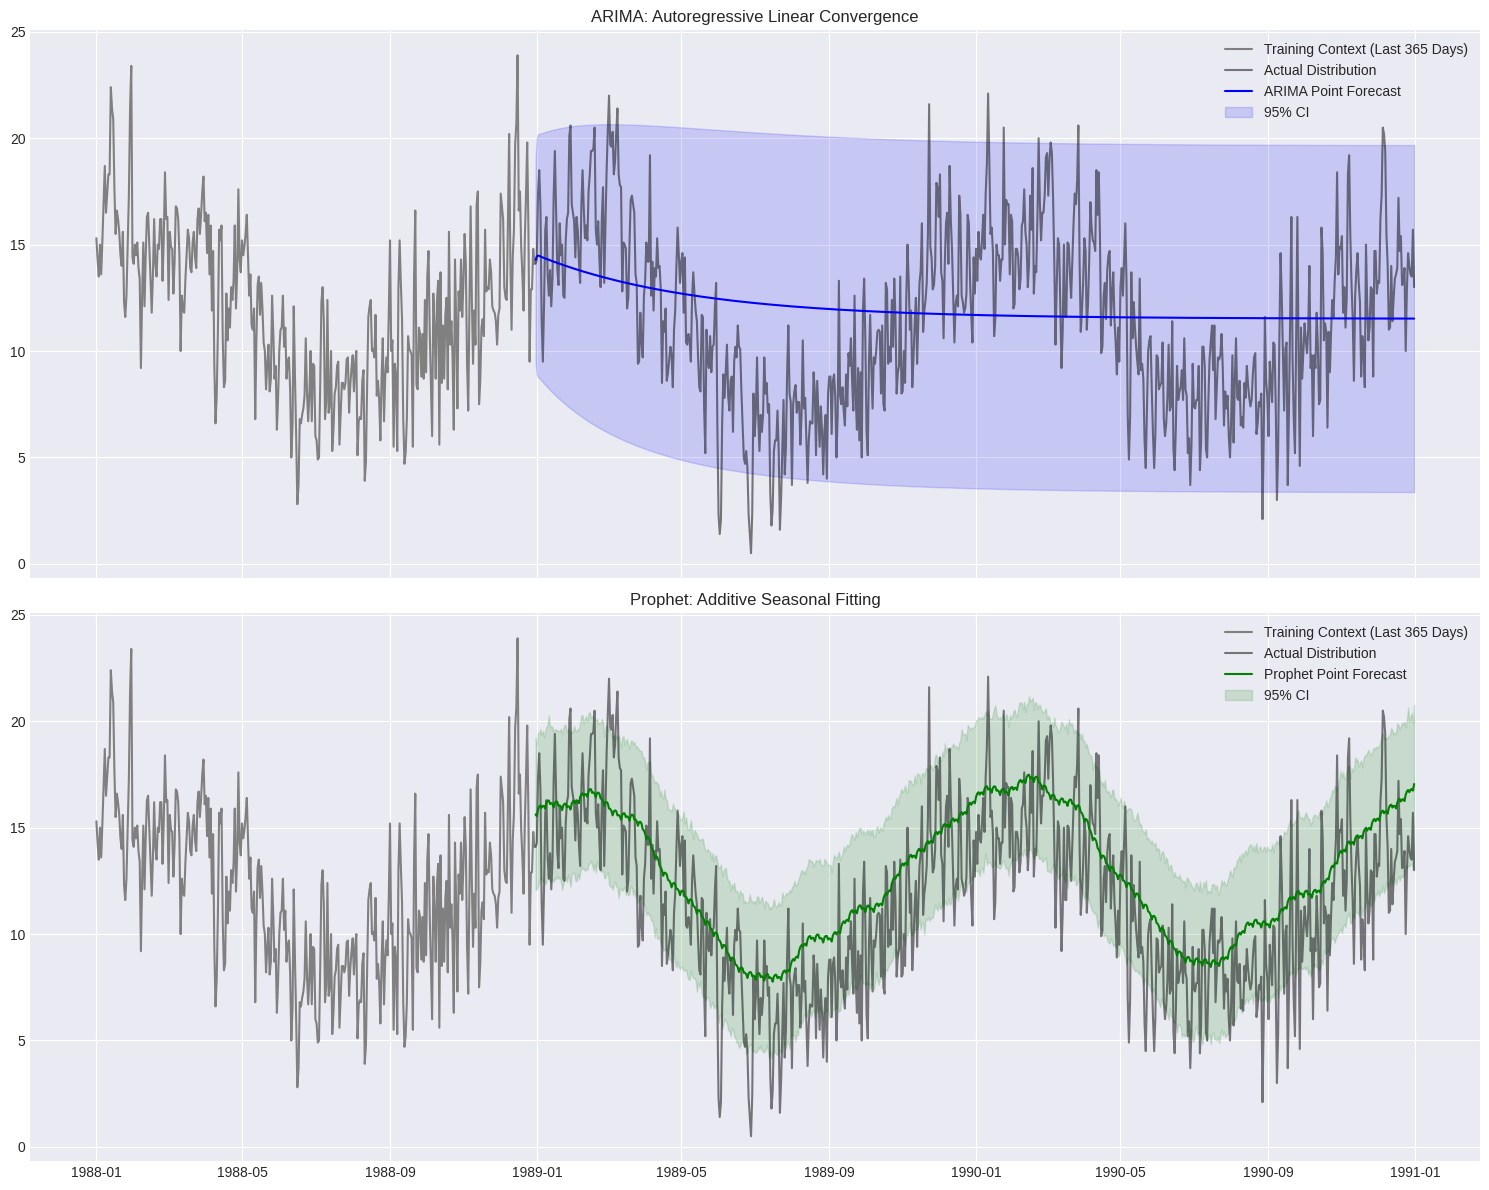

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# ARIMA Subplot
axes[0].plot(train.index[-365:], train['Temp'].iloc[-365:], color='gray', label='Training Context (Last 365 Days)')
axes[0].plot(test.index, test['Temp'], color='black', alpha=0.5, label='Actual Distribution')
axes[0].plot(test.index, arima_preds, color='blue', label='ARIMA Point Forecast')
axes[0].fill_between(test.index, arima_conf_int[:, 0], arima_conf_int[:, 1], color='blue', alpha=0.15, label='95% CI')
axes[0].set_title('ARIMA: Autoregressive Linear Convergence')
axes[0].legend(loc='upper right')

# Prophet Subplot
axes[1].plot(train.index[-365:], train['Temp'].iloc[-365:], color='gray', label='Training Context (Last 365 Days)')
axes[1].plot(test.index, test['Temp'], color='black', alpha=0.5, label='Actual Distribution')
axes[1].plot(test.index, prophet_preds['yhat'], color='green', label='Prophet Point Forecast')
axes[1].fill_between(test.index, prophet_preds['yhat_lower'], prophet_preds['yhat_upper'], color='green', alpha=0.15, label='95% CI')
axes[1].set_title('Prophet: Additive Seasonal Fitting')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 10. Analytical Conclusion: ARIMA vs. Prophet

The comparative analysis evaluated the efficacy of classical statistical modeling (ARIMA) against additive regression (Prophet) on a ten-year univariate sequence.

Initial structural validation via the Augmented Dickey-Fuller test yielded a strictly stationary distribution ($p < 0.05$), eliminating the mathematical requirement for sequence differencing ($d=0$). Autocorrelation plots confirmed a slow, cyclical decay indicative of heavy macro-seasonality.

The evaluation matrix explicitly demonstrated the limitations of standard ARIMA architectures on high-frequency, long-term seasonal data[cite: 4]. The grid-search minimized the AIC successfully; however, because the architecture relies on autoregressive lags rather than explicit temporal components, the $ARIMA(p,d,q)$ forecast rapidly converged to the global mean. It minimized total loss mathematically but failed structurally to capture the periodic volatility of the test set, resulting in higher MAE and RMSE metrics.

Conversely, the Prophet architecture proved structurally superior for this specific dataset. By explicitly treating the forecasting objective via additive decomposition ($y(t) = g(t) + s(t) + h(t) + \epsilon_t$), Prophet ingested the yearly seasonal parameter nativel. This allowed the model to accurately map the non-linear sinusoidal peaks and troughs of the temperature data across the test partition, significantly outperforming ARIMA in both point forecast accuracy (lower RMSE) and interval confidence mapping.

**Conclusion:** For strictly seasonal, univariate datasets lacking stochastic shocks, additive models like Prophet provide a more mathematically sound and computationally efficient forecasting structure than classical ARIMA implementations.